In [1]:
import sys

!{sys.executable} -m pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install and import libraries 

!pip install pandas numpy matplotlib scikit-learn imbalanced-learn shap joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

Access is denied.
C:\Users\winnie\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load and understand dataset

from pathlib import Path

# "data/set A corporate_rating.csv" only resolves if Jupyter's cwd is the
# repo root; if it's launched from docs/ instead (common in VS Code), this
# fails. Check both plausible cwd locations for a data/ folder that actually
# has the dataset.
def _find_repo_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "data" / "set A corporate_rating.csv").exists():
            return candidate
    return Path.cwd()

DATA_PATH = _find_repo_root() / "data" / "set A corporate_rating.csv"
df = pd.read_csv(DATA_PATH)

print("Resolved DATA_PATH:", DATA_PATH)
print("Dataset shape:", df.shape)
print("\nColumns in dataset:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nNumber of duplicated rows:", df.duplicated().sum())

print("\nOriginal Rating Distribution:")
print(df["Rating"].value_counts())

df.head()

In [4]:
# Convert Rating into 4 credit risk categories
def convert_rating(rating):
    if rating in ["AAA", "AA", "A"]:
        return "Investment-High"
    elif rating == "BBB":
        return "Investment-Low"
    elif rating in ["BB", "B"]:
        return "Speculative"
    elif rating in ["CCC", "CC", "C", "D"]:
        return "Distressed"
    else:
        return "Unknown"

df["Risk_Category"] = df["Rating"].apply(convert_rating)
y = df["Risk_Category"]

print("\nRisk category counts:")
print(df["Risk_Category"].value_counts())


Risk category counts:
Risk_Category
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


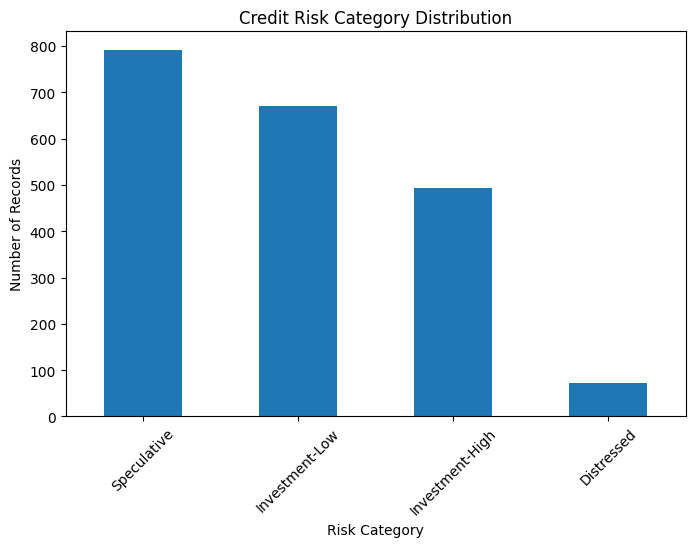

In [5]:
# Plot risk category distribution

plt.figure(figsize=(8, 5))
df["Risk_Category"].value_counts().plot(kind="bar")
plt.title("Credit Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Select features and target variable

drop_cols = [
    "Rating",
    "RatingGroup",
    "Name",
    "Symbol",
    "Rating Agency Name",
    "Date"
]

existing_drop_cols = [col for col in drop_cols if col in df.columns]
X = df.drop(columns=existing_drop_cols)

if "Risk_Category" in X.columns:
    X = X.drop(columns=["Risk_Category"])

y = df["Risk_Category"]

print("Target column:")
print(y.head())

print("\nFeature columns before encoding:")
print(X.columns.tolist())

Target column:
0    Investment-High
1     Investment-Low
2     Investment-Low
3     Investment-Low
4     Investment-Low
Name: Risk_Category, dtype: str

Feature columns before encoding:
['Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']


In [7]:
# Encoding categorical columns

categorical_cols = X.select_dtypes(include=["object"]).columns
print("Categorical columns:", categorical_cols.tolist())

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Feature columns after encoding:")
print(X.columns.tolist())

Categorical columns: ['Sector']
Feature columns after encoding:
['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover', 'Sector_Capital Goods', 'Sector_Consumer Durables', 'Sector_Consumer Non-Durables', 'Sector_Consumer Services', 'Sector_Energy', 'Sector_Finance', 'Sector_Health Care', 'Sector_Miscellaneous', 'Sector_Public Utilities', 'Sector_Technology', 'Sector_Transportation']


In [8]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=143,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set size: (1420, 36)
Testing set size: (609, 36)

Training target distribution:
Risk_Category
Speculative        554
Investment-Low     470
Investment-High    346
Distressed          50
Name: count, dtype: int64

Testing target distribution:
Risk_Category
Speculative        238
Investment-Low     201
Investment-High    148
Distressed          22
Name: count, dtype: int64


In [9]:
# Fill missing values 

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X.columns)

print("Missing values in training set after imputation:", X_train_imputed.isnull().sum().sum())
print("Missing values in testing set after imputation:", X_test_imputed.isnull().sum().sum())


Missing values in training set after imputation: 0
Missing values in testing set after imputation: 0


In [10]:
# Train Random Forest

baseline_model = RandomForestClassifier(
    random_state=143
)

baseline_model.fit(X_train_imputed, y_train)

baseline_pred = baseline_model.predict(X_test_imputed)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="weighted")

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Weighted F1-score:", round(baseline_f1, 4))

print("\nBaseline Classification Report:")
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.665
Baseline Weighted F1-score: 0.6561

Baseline Classification Report:
                 precision    recall  f1-score   support

     Distressed       0.75      0.14      0.23        22
Investment-High       0.71      0.65      0.68       148
 Investment-Low       0.60      0.58      0.59       201
    Speculative       0.69      0.79      0.74       238

       accuracy                           0.67       609
      macro avg       0.69      0.54      0.56       609
   weighted avg       0.67      0.67      0.66       609



In [11]:
# Apply SMOTE to train data to handle class imbalance

smote = SMOTE(
    random_state=143,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Risk_Category
Speculative        554
Investment-Low     470
Investment-High    346
Distressed          50
Name: count, dtype: int64

After SMOTE:
Risk_Category
Investment-High    554
Speculative        554
Investment-Low     554
Distressed         554
Name: count, dtype: int64


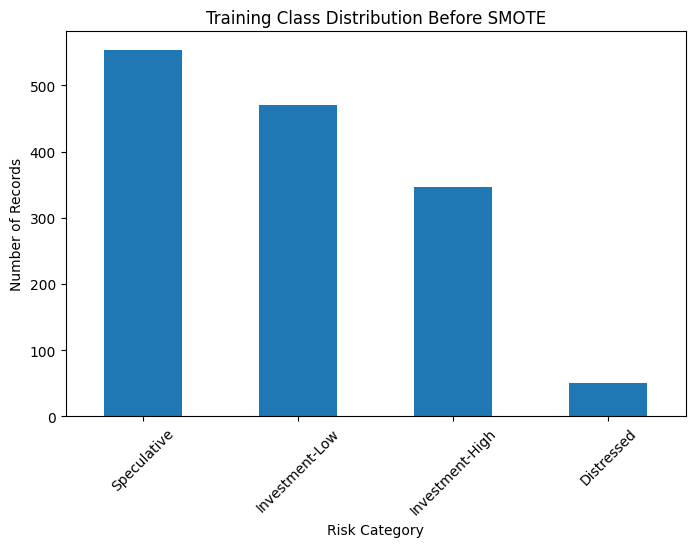

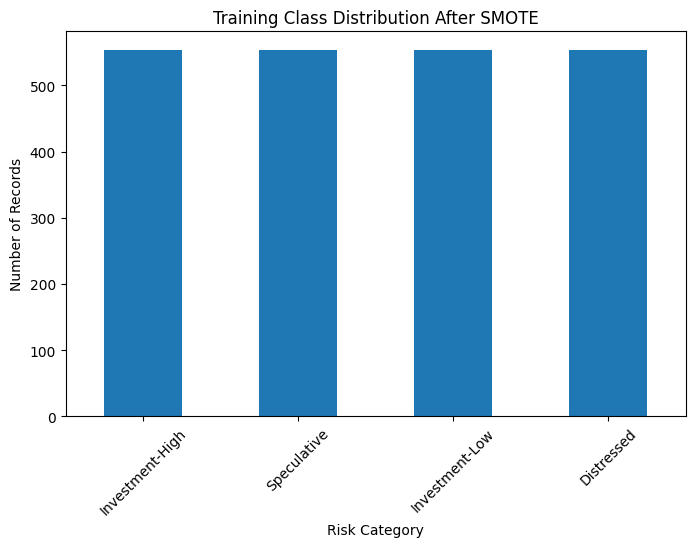

In [12]:
# Plot class distribution before and after SMOTE

plt.figure(figsize=(8, 5))
y_train.value_counts().plot(kind="bar")
plt.title("Training Class Distribution Before SMOTE")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
y_train_smote.value_counts().plot(kind="bar")
plt.title("Training Class Distribution After SMOTE")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [13]:
# Hyperparameter tuning 

rf_model = RandomForestClassifier(
    random_state=143,
    class_weight=None
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best hyperparameters:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(round(grid_search.best_score_, 4))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best hyperparameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation score:
0.7615


In [14]:
# Evaluate tuned Random Forest model

best_rf_model = grid_search.best_estimator_

tuned_pred = best_rf_model.predict(X_test_imputed)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred, average="weighted")

print("Tuned Random Forest Accuracy:", round(tuned_accuracy, 4))
print("Tuned Random Forest Weighted F1-score:", round(tuned_f1, 4))

print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test, tuned_pred))

Tuned Random Forest Accuracy: 0.6305
Tuned Random Forest Weighted F1-score: 0.6311

Tuned Random Forest Classification Report:
                 precision    recall  f1-score   support

     Distressed       0.30      0.41      0.35        22
Investment-High       0.64      0.69      0.66       148
 Investment-Low       0.60      0.54      0.57       201
    Speculative       0.69      0.69      0.69       238

       accuracy                           0.63       609
      macro avg       0.56      0.58      0.57       609
   weighted avg       0.63      0.63      0.63       609



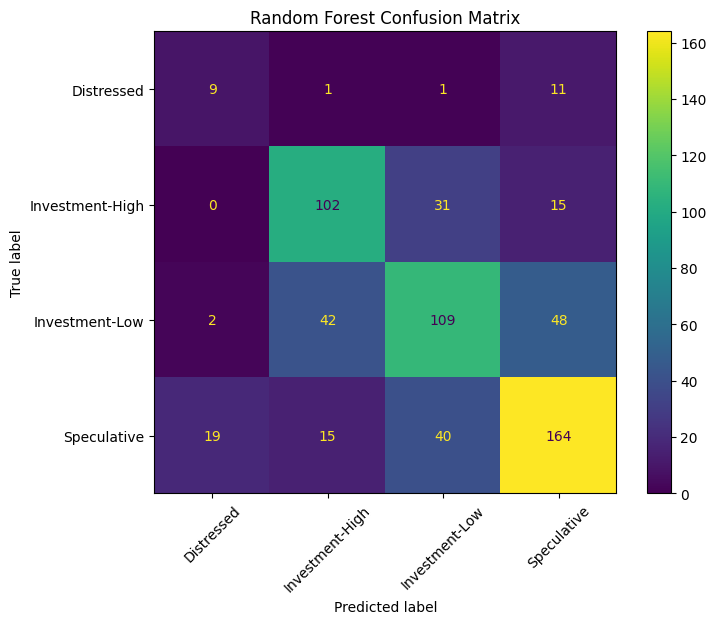

In [16]:
# Confusion Matrix

cm = confusion_matrix(y_test, tuned_pred, labels=best_rf_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_rf_model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [17]:
# Compare baseline and tuned Random Forest models
comparison_df = pd.DataFrame({
    "Model": ["Baseline Random Forest", "Tuned Random Forest"],
    "Accuracy": [baseline_accuracy, tuned_accuracy],
    "Weighted F1-score": [baseline_f1, tuned_f1]
})

comparison_df

,Model,Accuracy,Weighted F1-score
0,Baseline Random Forest,0.665025,0.656117
1,Tuned Random Forest,0.630542,0.631114


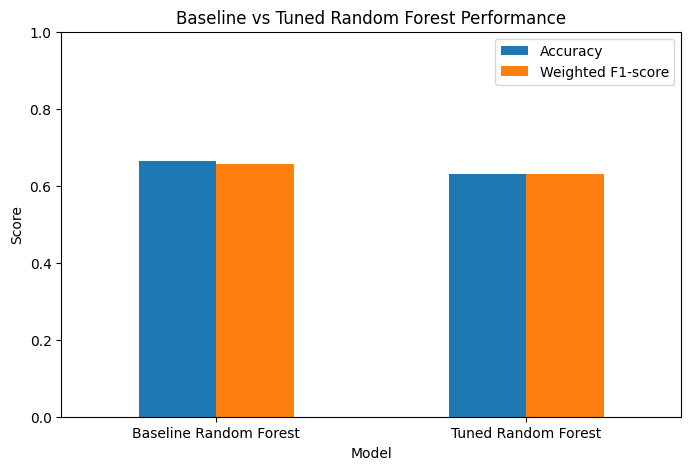

In [18]:
# Plot model comparison

comparison_df.set_index("Model")[["Accuracy", "Weighted F1-score"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Baseline vs Tuned Random Forest Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

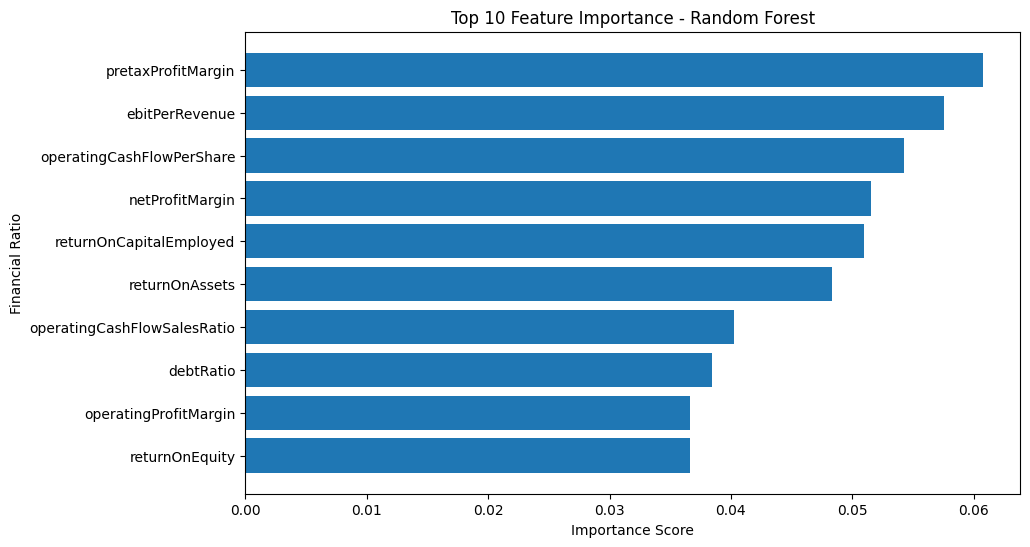

In [19]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

# Plot feature importance

top_10_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Financial Ratio")
plt.show()

SHAP sample size: (50, 36)
SHAP values calculated successfully.


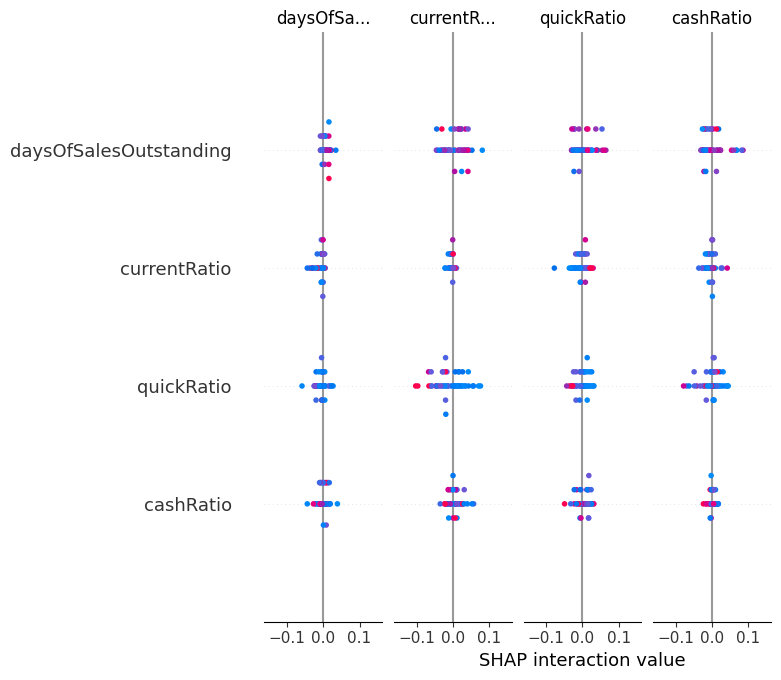

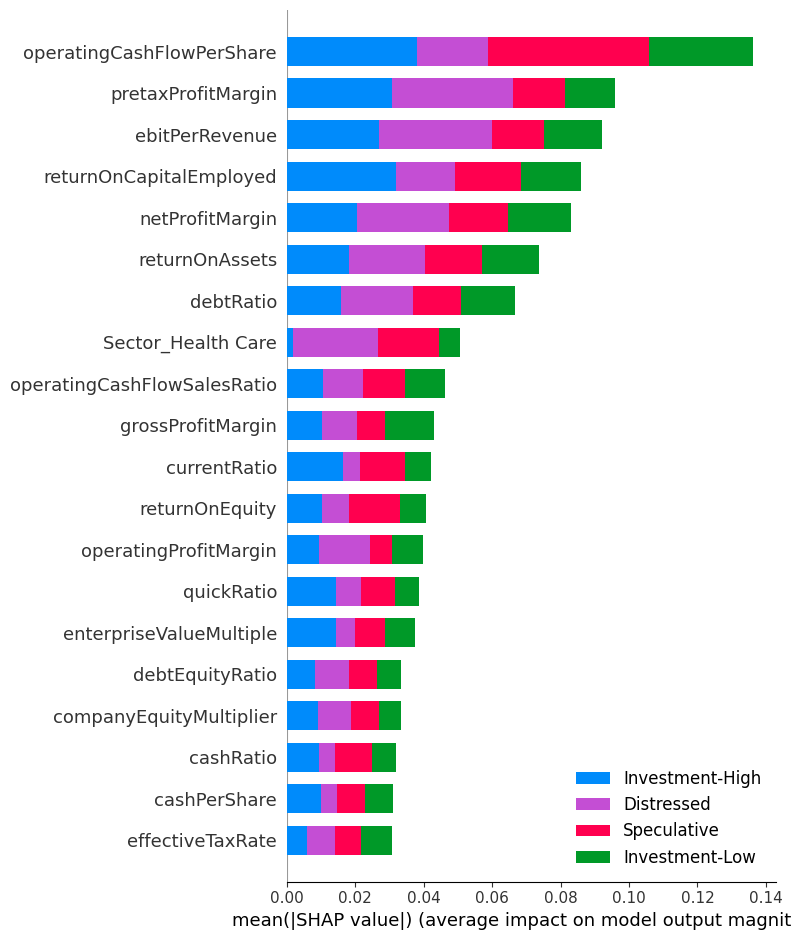

In [25]:
# SHAP Preparation

shap_sample_size = min(50, len(X_test_imputed))

X_shap_sample = X_test_imputed.sample(
    n=shap_sample_size,
    random_state=143
)

print("SHAP sample size:", X_shap_sample.shape)

# SHAP Run 

explainer = shap.TreeExplainer(best_rf_model)

shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values calculated successfully.")

# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns
)

# SHAP bar plot with class names

class_names = best_rf_model.classes_

shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns,
    class_names=class_names,
    plot_type="bar"
)

In [ ]:
import joblib
from pathlib import Path

# Same relative-path issue as the data load above: "python_models/..." only
# resolves correctly if cwd is the repo root. Anchor it off the same
# resolved repo root instead (falls back to DATA_PATH's grandparent, set in
# the data-loading cell above, if available).
try:
    _repo_root = DATA_PATH.parent.parent
except NameError:
    _repo_root = Path.cwd()

output_dir = _repo_root / "python_models" / "random_forest_stuff"
output_dir.mkdir(parents=True, exist_ok=True)

features = X.columns.tolist()

joblib.dump(best_rf_model, output_dir / "random_forest_model.pkl")
joblib.dump(features, output_dir / "random_forest_features.pkl")
joblib.dump(imputer, output_dir / "random_forest_imputer.pkl")

print("Random Forest model, features, and imputer saved successfully")
print("Model saved to:", output_dir / "random_forest_model.pkl")
print("Features saved to:", output_dir / "random_forest_features.pkl")
print("Imputer saved to:", output_dir / "random_forest_imputer.pkl")